https://www.statsmodels.org/stable/examples/index.html#state-space-models

In [1]:
import sys
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from tqdm import tqdm
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import gruanpy as gp
from ssm.statsmodels.local_trend import LocalLinearTrend

In [2]:
base = os.path.abspath(os.path.join(os.getcwd(), ".."))
pkl_path = os.path.join(base, "pblh_unc", "pkls", "gdp_2024_HKO-RS-01_2024.pkl")

with open(pkl_path, "rb") as f:
    dataset = pickle.load(f)

print("Dataset Loaded")

def gdp_iterator(dataset):
    for pid, gdp in dataset.items():
        yield pid, gdp
iterator = gdp_iterator(dataset)

Dataset Loaded


In [3]:
pid, gdp = next(iterator)
print(pid)

857565


In [4]:
upper_bound = gp._find_upper_bound(gdp.data[['alt']], upper_bound=3500, return_value=True)
gdp.data = gdp.data[gdp.data['alt'] <= upper_bound]
data=gdp.data

In [5]:
COEF=1
cols=['alt', 'temp', 'rh', 'press', 'wvmr_mass', 'wzon', 'wmeri']
if COEF!=1:
    for col in cols:
        data[col+'_uc']=data[col+'_uc']*COEF

In [6]:
# -----------------------------
# TIME
# -----------------------------
start = data['time'].values[0]
time = data['time'].values
seconds = (time - start) / np.timedelta64(1, 's')
seconds = seconds.astype(float)

# -----------------------------
# ALTITUDE
# -----------------------------
z = data['alt'].values.astype(float)
z_unc  = data['alt_gph_uc'].values
z_var  = (z_unc * 0.5)**2


# -----------------------------
# TEMPERATURE
# -----------------------------
T      = data['temp'].values
T_unc  = data['temp_uc'].values
T_var  = (T_unc * 0.5)**2


# -----------------------------
# PRESSURE
# -----------------------------
p      = data['press'].values
p_unc  = data['press_uc'].values
p_var  = (p_unc * 0.5)**2


# -----------------------------
# RELATIVE HUMIDITY
# -----------------------------
RH     = data['rh'].values
RH_unc = data['rh_uc'].values
RH_var = (RH_unc * 0.5)**2


# -----------------------------
# WATER-VAPOR MASS MIXING RATIO (ppm → kg/kg)
# -----------------------------
r_ppm     = data['wvmr_mass'].values
r_ppm_unc = data['wvmr_mass_uc'].values

# convert ppm → kg/kg
r         = r_ppm * 1e-6
r_unc     = r_ppm_unc * 1e-6
r_var     = (r_unc * 0.5)**2


# -----------------------------
# ZONAL WIND
# -----------------------------
u      = data['wzon'].values
u_unc  = data['wzon_uc'].values
u_var  = (u_unc * 0.5)**2


# -----------------------------
# MERIDIONAL WIND
# -----------------------------
v      = data['wmeri'].values
v_unc  = data['wmeri_uc'].values
v_var  = (v_unc * 0.5)**2


# -----------------------------
# PRE-TRASFORMATION OF VIRTUAL POTENTIAL TEMPERATURE
# -----------------------------

Thv     = gp.virtual_potential_temperature(T, p, r)
Thv_unc  = gp.virtual_potential_temperature_uncertainty(T, p, r, T_unc, p_unc, r_unc,)
Thv_var = (Thv_unc * 0.5)**2

# -----------------------------
# FIT MODEL
# ----------------------------- 
endog=np.column_stack([z, Thv, RH, u, v])
measurement_var = np.column_stack([z_var, Thv_var, RH_var, u_var, v_var]).T


In [7]:
# Setup the model
model = LocalLinearTrend(endog=endog, measurement_var=measurement_var)

# Fit it using MLE with a fixed sequence of measurement variances
results = model.fit(method='powell',
            maxiter=100,
            full_output=1,
            disp=5)

Optimization terminated successfully.
         Current function value: 7.051816
         Iterations: 6
         Function evaluations: 821


In [8]:
# Setup the model

from ssm.statsmodels.local_level import MeasurementLocalLevel
model = MeasurementLocalLevel(endog=endog, measurement_var=measurement_var,
                         measurement_names=['alt', 'temp', 'rh', 'u', 'v'])

# Fit it using MLE with a fixed sequence of measurement variances
results = model.fit(method='powell',
            maxiter=100,
            full_output=1,
            disp=5)

Optimization terminated successfully.
         Current function value: 8.413188
         Iterations: 3
         Function evaluations: 203


In [9]:
# - Print a table summarizing estimation results
print(results.summary())


                                 Statespace Model Results                                 
Dep. Variable:     ['y1', 'y2', 'y3', 'y4', 'y5']   No. Observations:                  643
Model:                      MeasurementLocalLevel   Log Likelihood               -5409.680
Date:                            Wed, 29 Jul 2026   AIC                          10829.359
Time:                                    14:53:45   BIC                          10851.651
Sample:                                         0   HQIC                         10838.013
                                            - 643                                         
Covariance Type:                              opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
alt_sigma2.level     47.5582     17.920      2.654      0.008      12.436      82.680
temp_sigma2.le

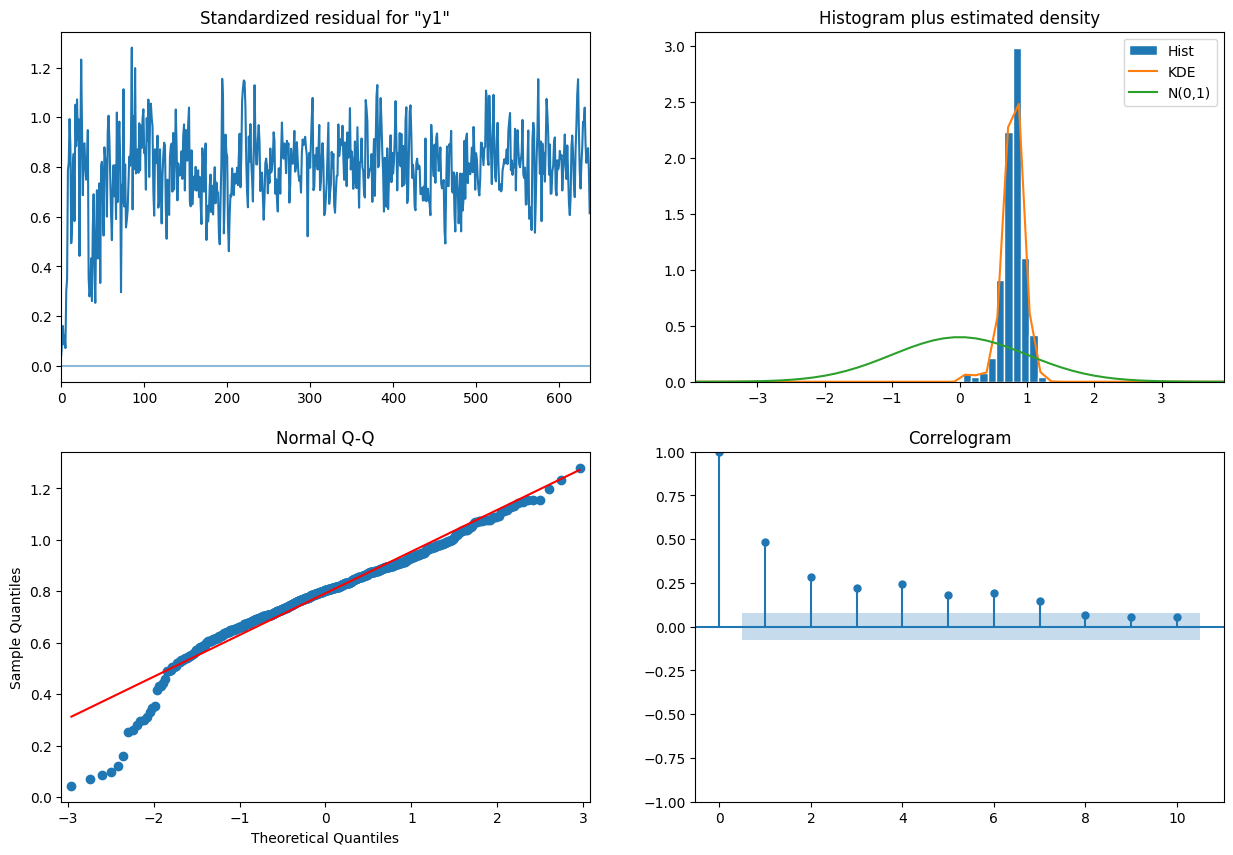

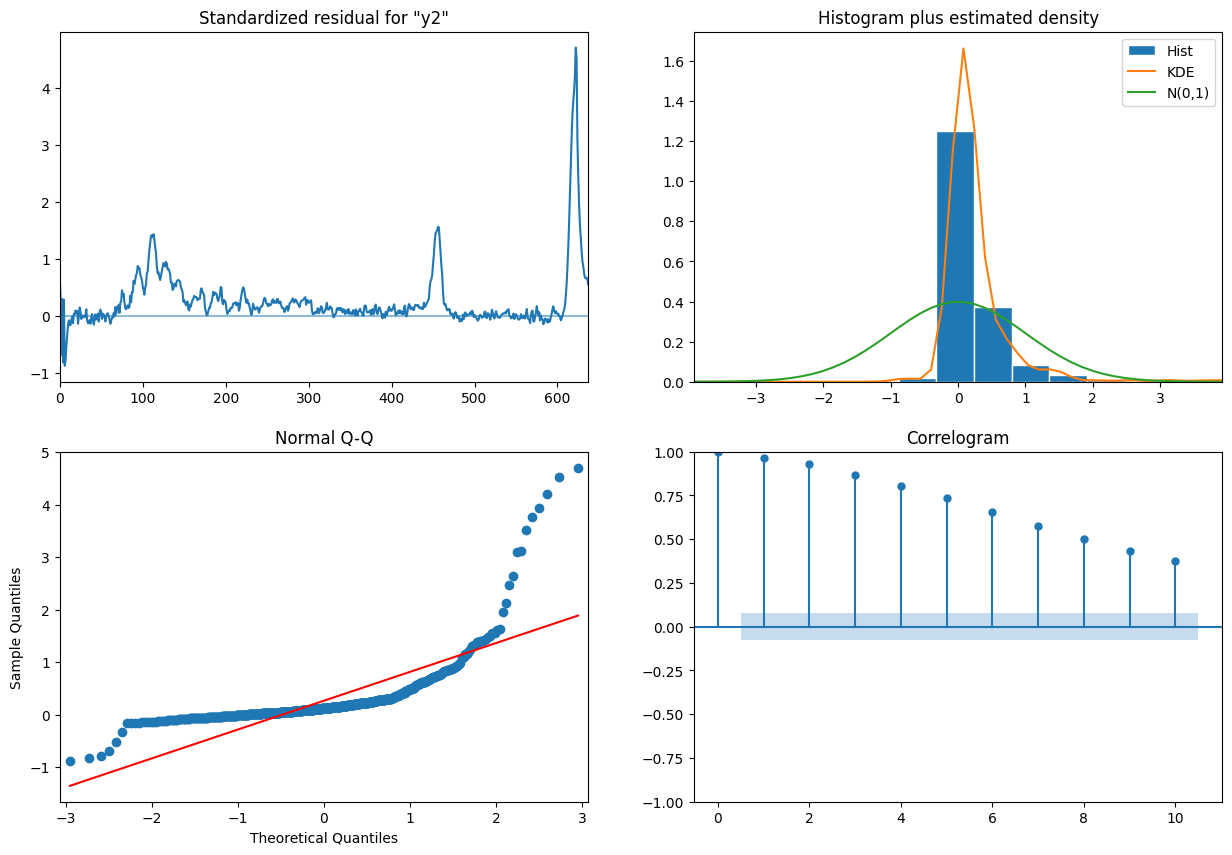

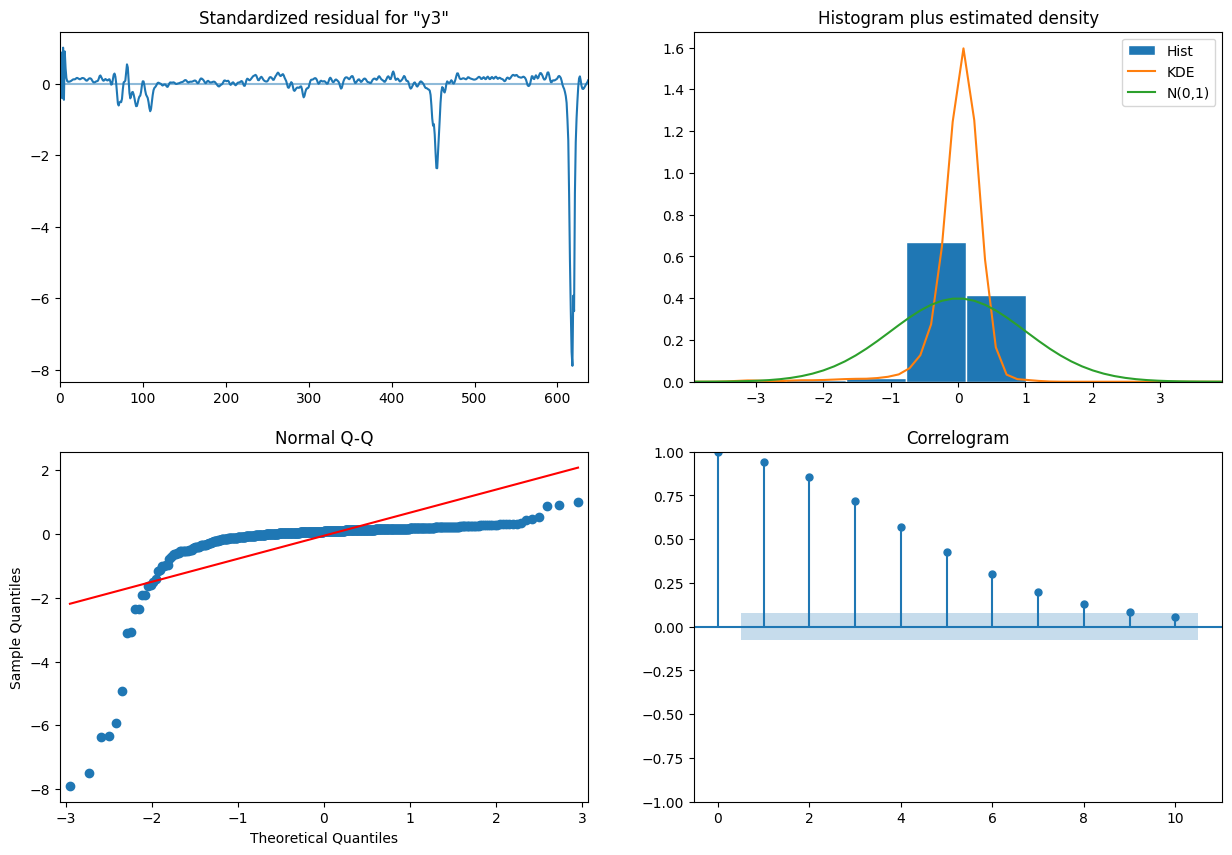

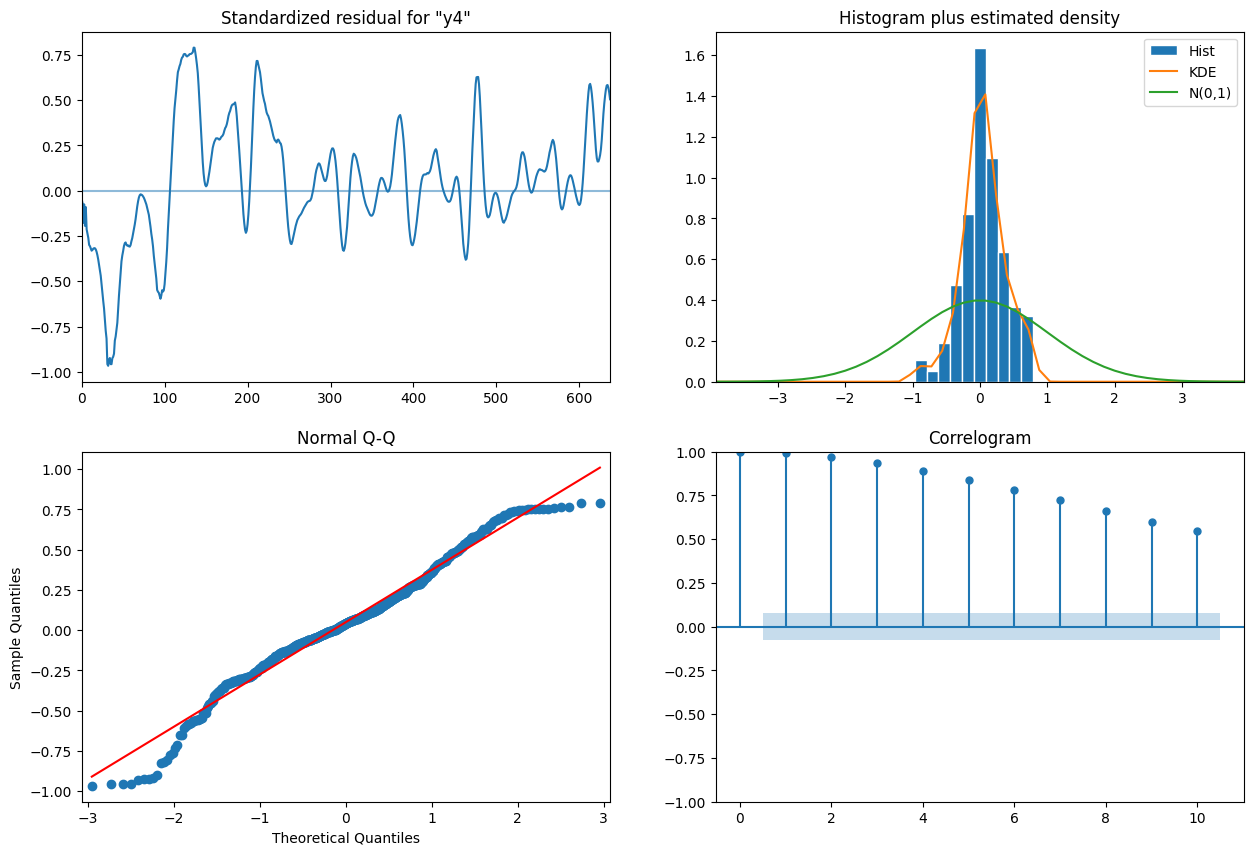

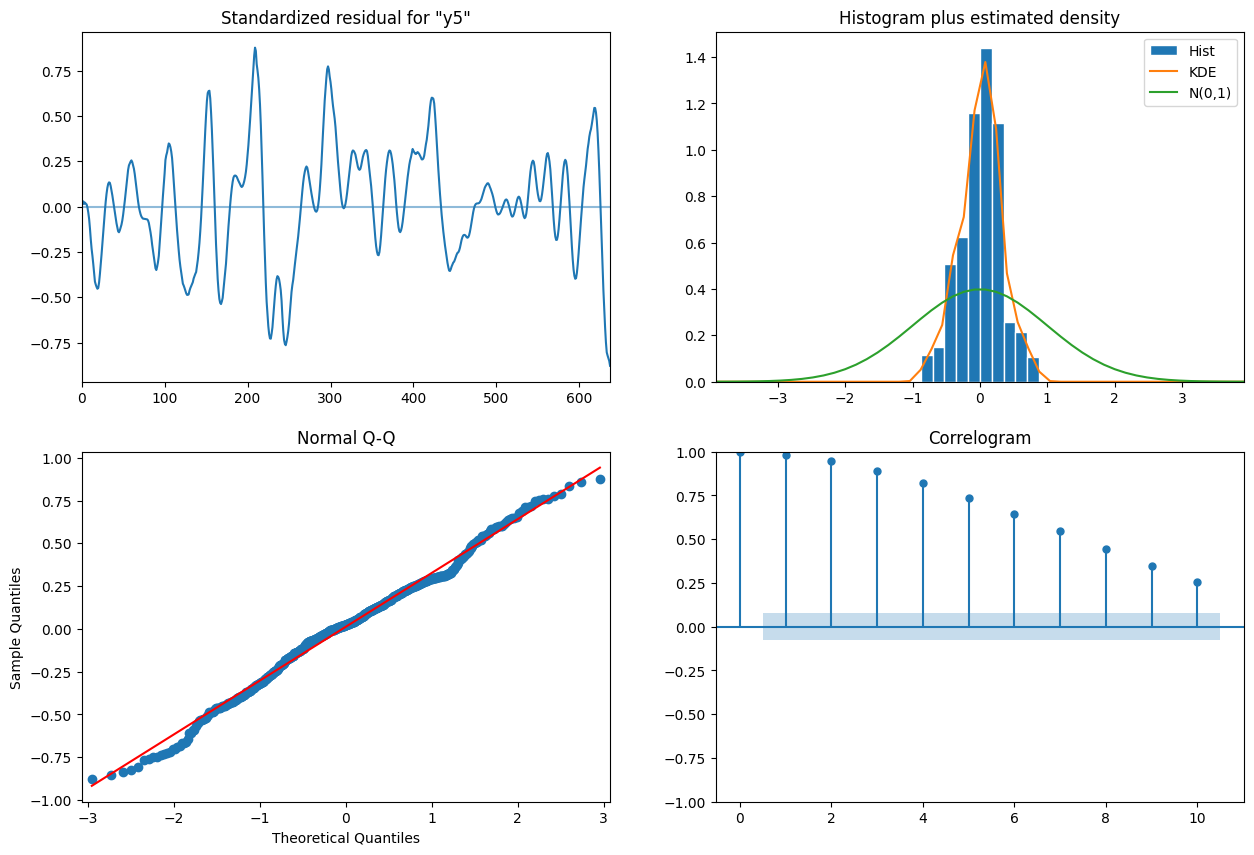

In [10]:
# - Create diagnostic figures based on standardized residuals:
#   (1) time series graph
#   (2) histogram
#   (3) Q-Q plot
#   (4) correlogram
for var in range(5):
    fig=results.plot_diagnostics(variable=var)
    fig.set_size_inches(15,10)
    plt.show(block=True)

In [17]:
"""
Univariate Local Linear Trend Model
"""


class UnivariateLocalLinearTrend(sm.tsa.statespace.MLEModel):
    def __init__(self, endog):
        # Model order
        k_states = k_posdef = 2

        # Initialize the statespace
        super(UnivariateLocalLinearTrend, self).__init__(
            endog,
            k_states=k_states,
            k_posdef=k_posdef,
            initialization="approximate_diffuse",
            loglikelihood_burn=k_states,
        )

        # Initialize the matrices
        self.ssm["design"] = np.array([1, 0])
        self.ssm["transition"] = np.array([[1, 1], [0, 1]])
        self.ssm["selection"] = np.eye(k_states)

        # Cache some indices
        self._state_cov_idx = ("state_cov",) + np.diag_indices(k_posdef)

    @property
    def param_names(self):
        return ["sigma2.measurement", "sigma2.level", "sigma2.trend"]

    @property
    def start_params(self):
        return [np.std(self.endog)] * 3

    def transform_params(self, unconstrained):
        return unconstrained**2

    def untransform_params(self, constrained):
        return constrained**0.5

    def update(self, params, *args, **kwargs):
        params = super(UnivariateLocalLinearTrend, self).update(params, *args, **kwargs)

        # Observation covariance
        self.ssm["obs_cov", 0, 0] = params[0]

        # State covariance
        self.ssm[self._state_cov_idx] = params[1:]

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood               -1038.667
Date:                        Wed, 29 Jul 2026   AIC                           2083.334
Time:                                11:50:27   BIC                           2096.723
Sample:                                     0   HQIC                          2088.531
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement  1.483e-11      0.048   3.07e-10      1.000      -0.095       0.095
sigma2.level           1.2222      0.125   

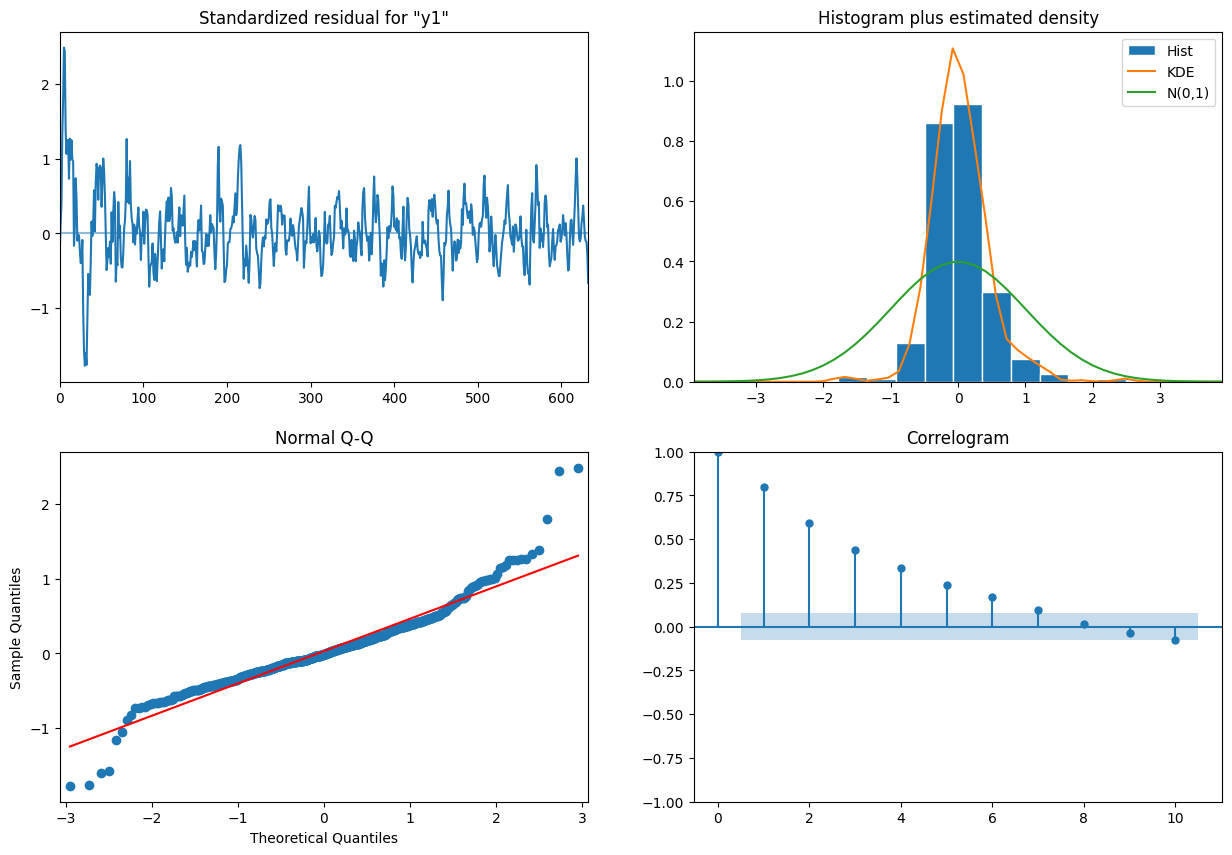

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood               -1038.667
Date:                        Wed, 29 Jul 2026   AIC                           2083.334
Time:                                11:50:28   BIC                           2096.723
Sample:                                     0   HQIC                          2088.531
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement  1.483e-11      0.048   3.07e-10      1.000      -0.095       0.095
sigma2.level           1.2222      0.125   

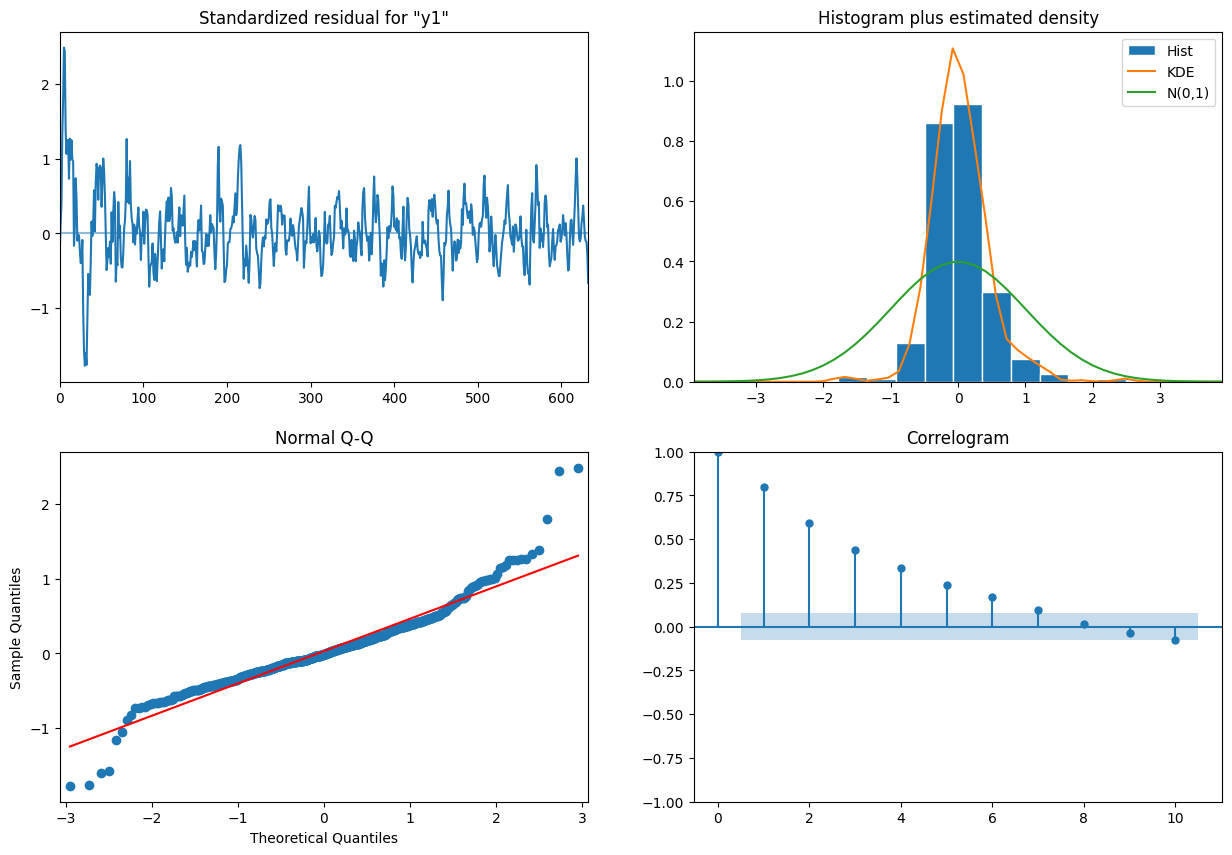

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood               -1038.667
Date:                        Wed, 29 Jul 2026   AIC                           2083.334
Time:                                11:50:29   BIC                           2096.723
Sample:                                     0   HQIC                          2088.531
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement  1.483e-11      0.048   3.07e-10      1.000      -0.095       0.095
sigma2.level           1.2222      0.125   

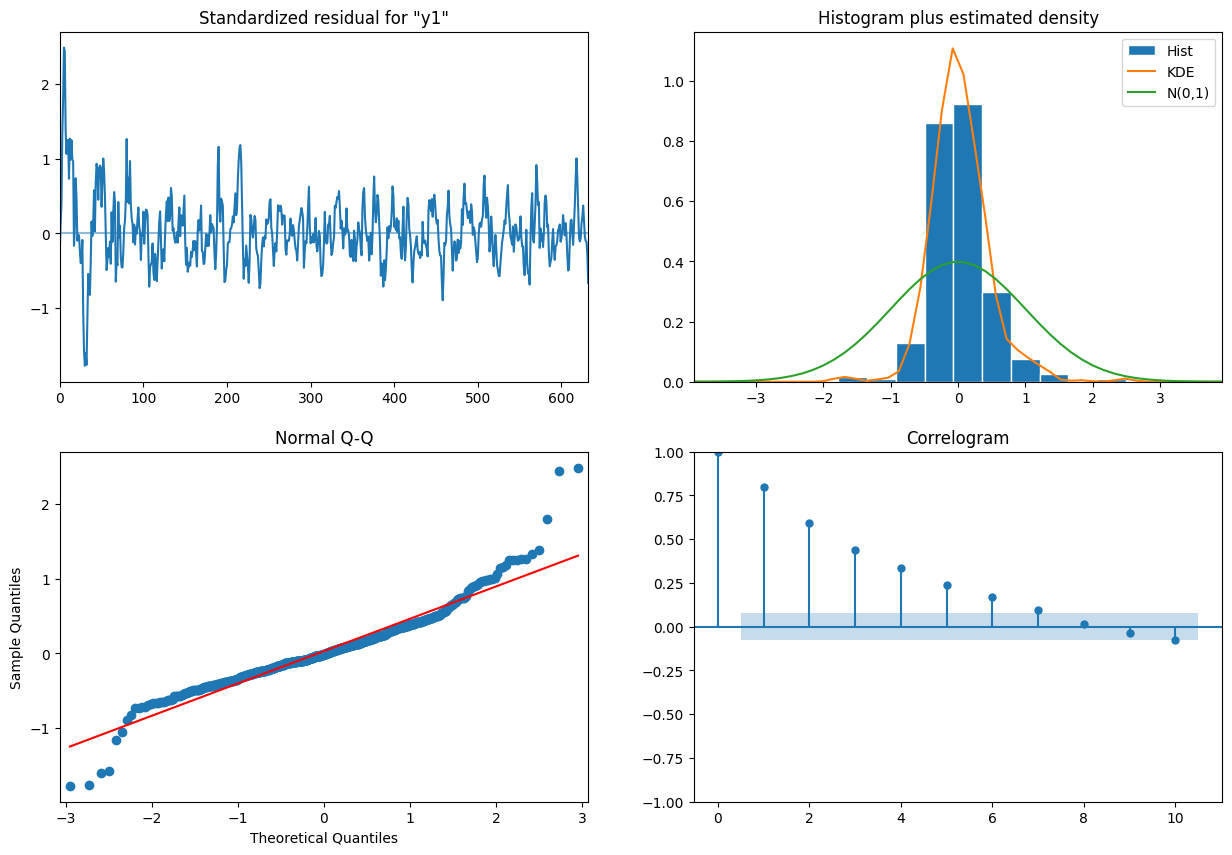

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood               -1038.667
Date:                        Wed, 29 Jul 2026   AIC                           2083.334
Time:                                11:50:30   BIC                           2096.723
Sample:                                     0   HQIC                          2088.531
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement  1.483e-11      0.048   3.07e-10      1.000      -0.095       0.095
sigma2.level           1.2222      0.125   

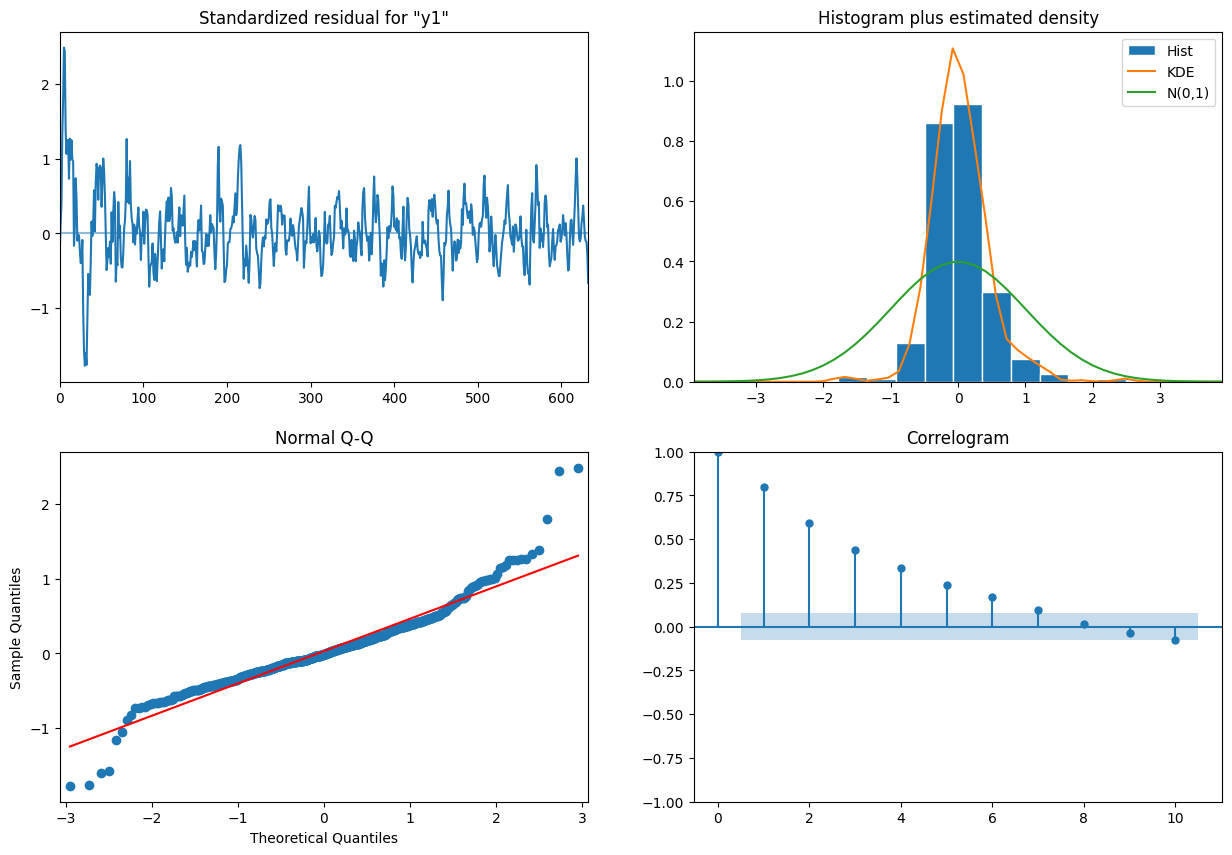

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood               -1038.667
Date:                        Wed, 29 Jul 2026   AIC                           2083.334
Time:                                11:50:31   BIC                           2096.723
Sample:                                     0   HQIC                          2088.531
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement  1.483e-11      0.048   3.07e-10      1.000      -0.095       0.095
sigma2.level           1.2222      0.125   

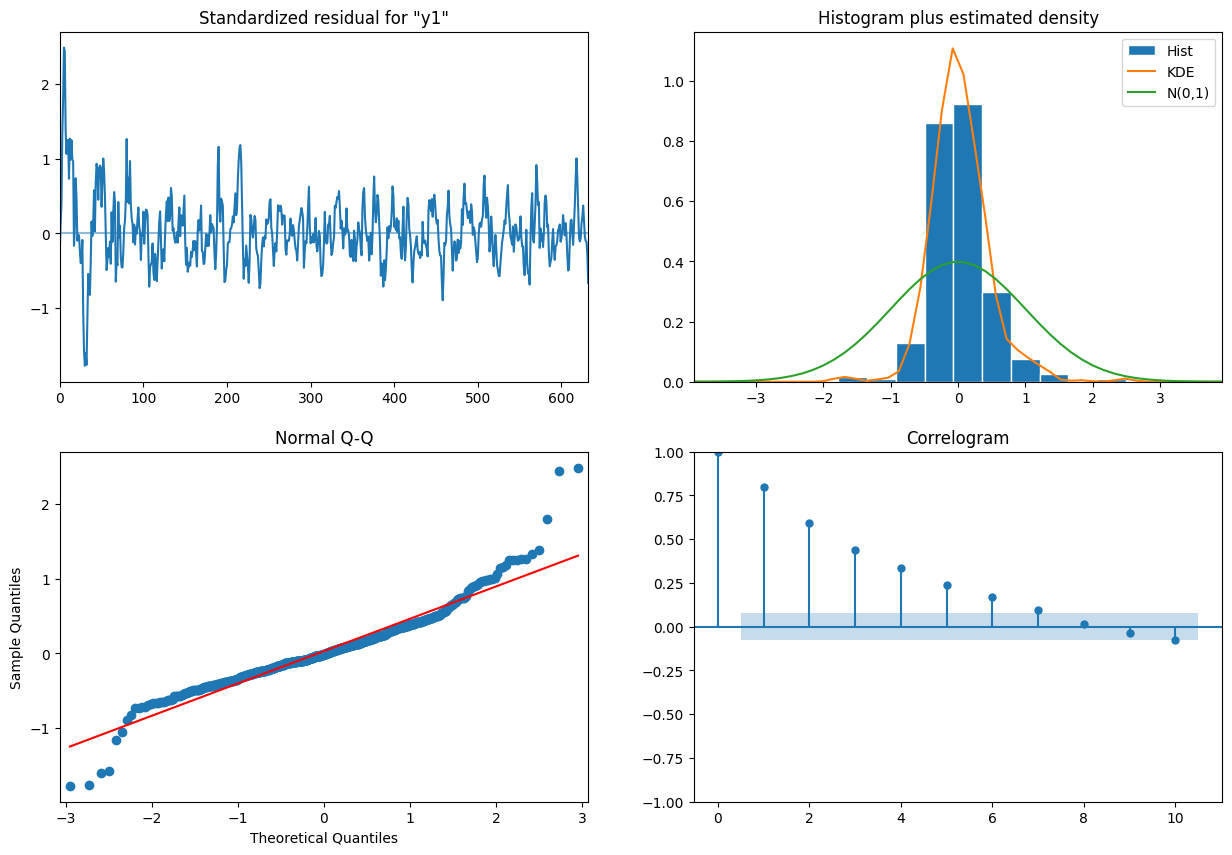

In [ ]:
for var in [z, Thv, RH, u, v]:
    # Setup the model
    mod = UnivariateLocalLinearTrend(z)

    # Fit it using MLE (recall that we are fitting the three variance parameters)
    res = mod.fit(disp=False)
    print(res.summary())
    fig=results.plot_diagnostics()
    fig.set_size_inches(15,10)
    plt.show(block=True)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 4)   Log Likelihood               -1026.542
Date:                Wed, 29 Jul 2026   AIC                           2067.084
Time:                        12:23:06   BIC                           2098.336
Sample:                             0   HQIC                          2079.212
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.7861      0.211      3.732      0.000       0.373       1.199
ar.L1          0.8549      0.039     21.743      0.000       0.778       0.932
ma.L1         -0.6148      0.049    -12.600      0.0

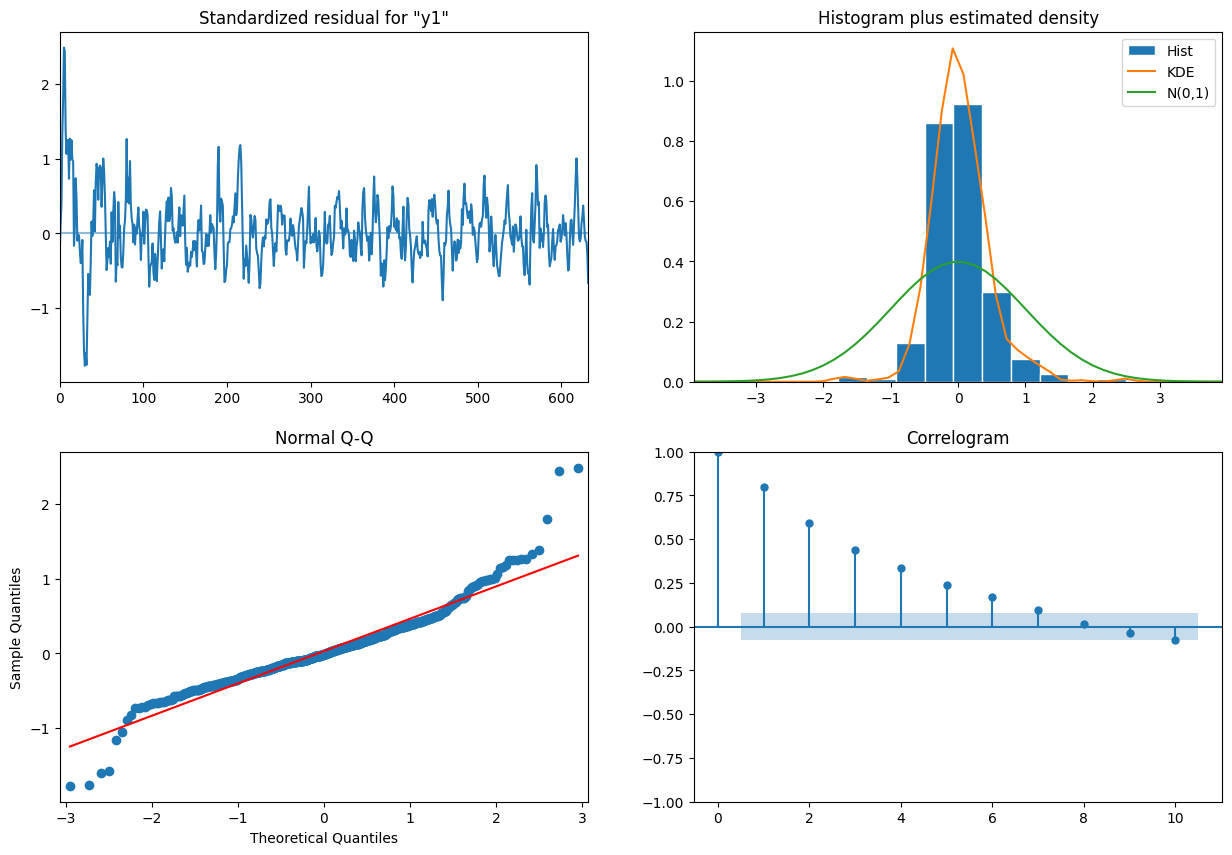

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 4)   Log Likelihood                1289.335
Date:                Wed, 29 Jul 2026   AIC                          -2564.671
Time:                        12:23:08   BIC                          -2533.418
Sample:                             0   HQIC                         -2552.542
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0030      0.001      2.044      0.041       0.000       0.006
ar.L1          0.9152      0.011     85.319      0.000       0.894       0.936
ma.L1         -0.7189      0.015    -48.766      0.0

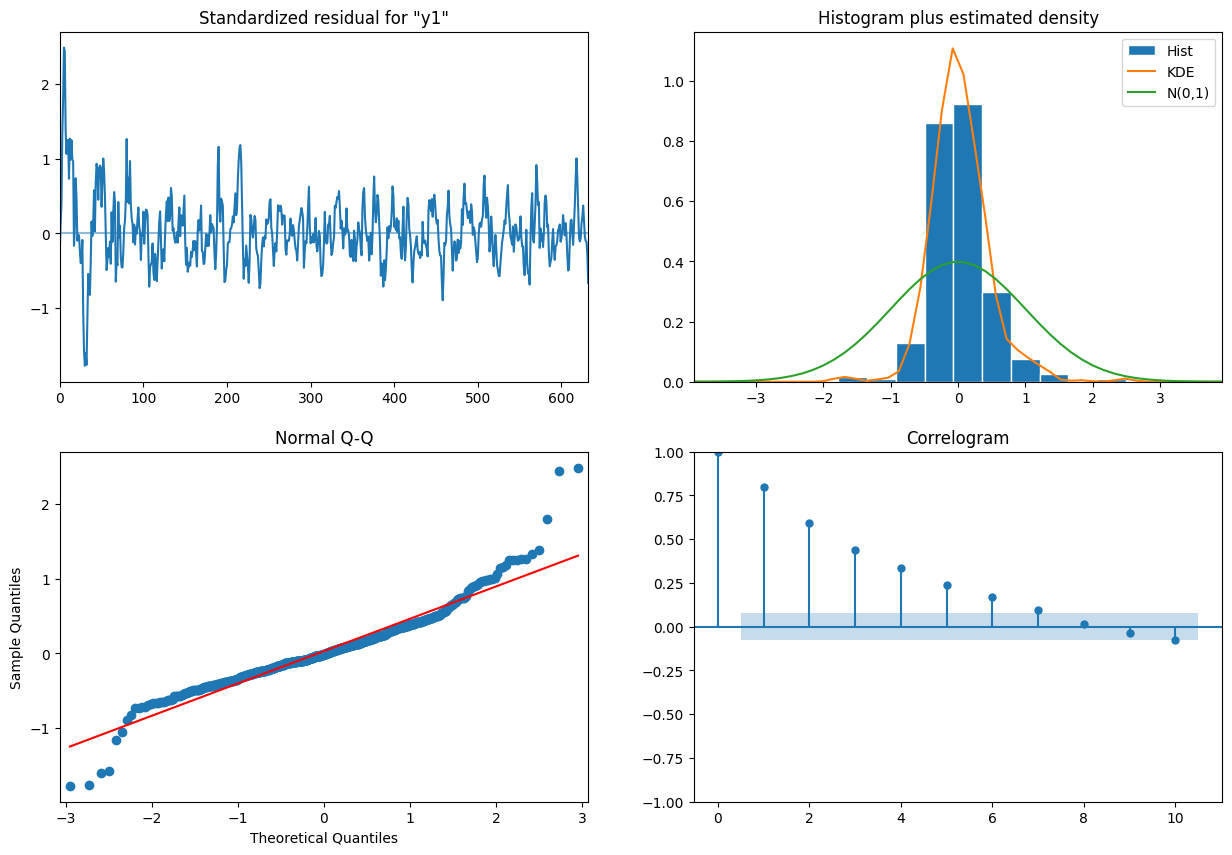

c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 4)   Log Likelihood                -381.356
Date:                Wed, 29 Jul 2026   AIC                            776.711
Time:                        12:23:10   BIC                            807.963
Sample:                             0   HQIC                           788.840
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0282      0.052     -0.544      0.587      -0.130       0.073
ar.L1          0.7523      0.018     42.975      0.000       0.718       0.787
ma.L1          0.2910      0.019     15.704      0.0

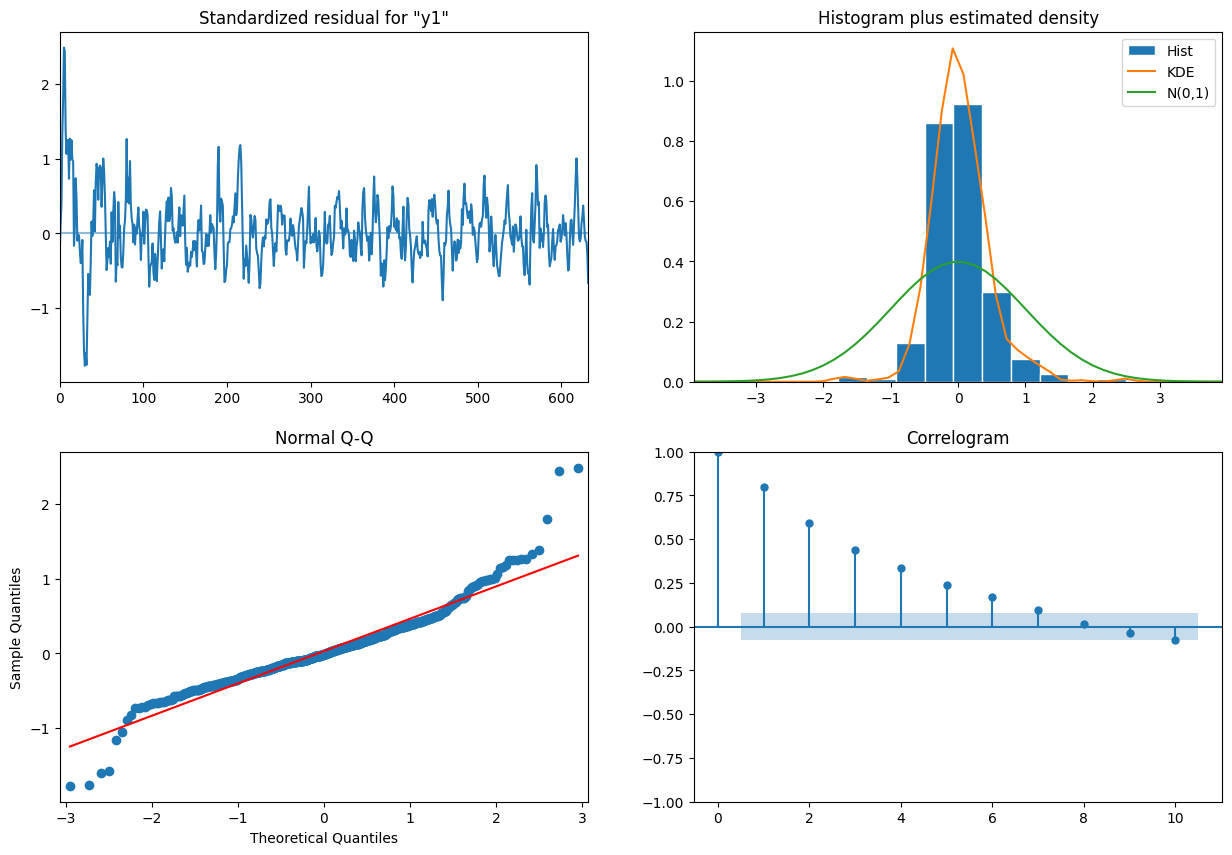

c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 4)   Log Likelihood                1167.151
Date:                Wed, 29 Jul 2026   AIC                          -2320.302
Time:                        12:23:13   BIC                          -2289.049
Sample:                             0   HQIC                         -2308.173
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0009      0.002      0.351      0.726      -0.004       0.006
ar.L1          0.9448      0.016     58.423      0.000       0.913       0.976
ma.L1         -0.9199      0.022    -42.241      0.0

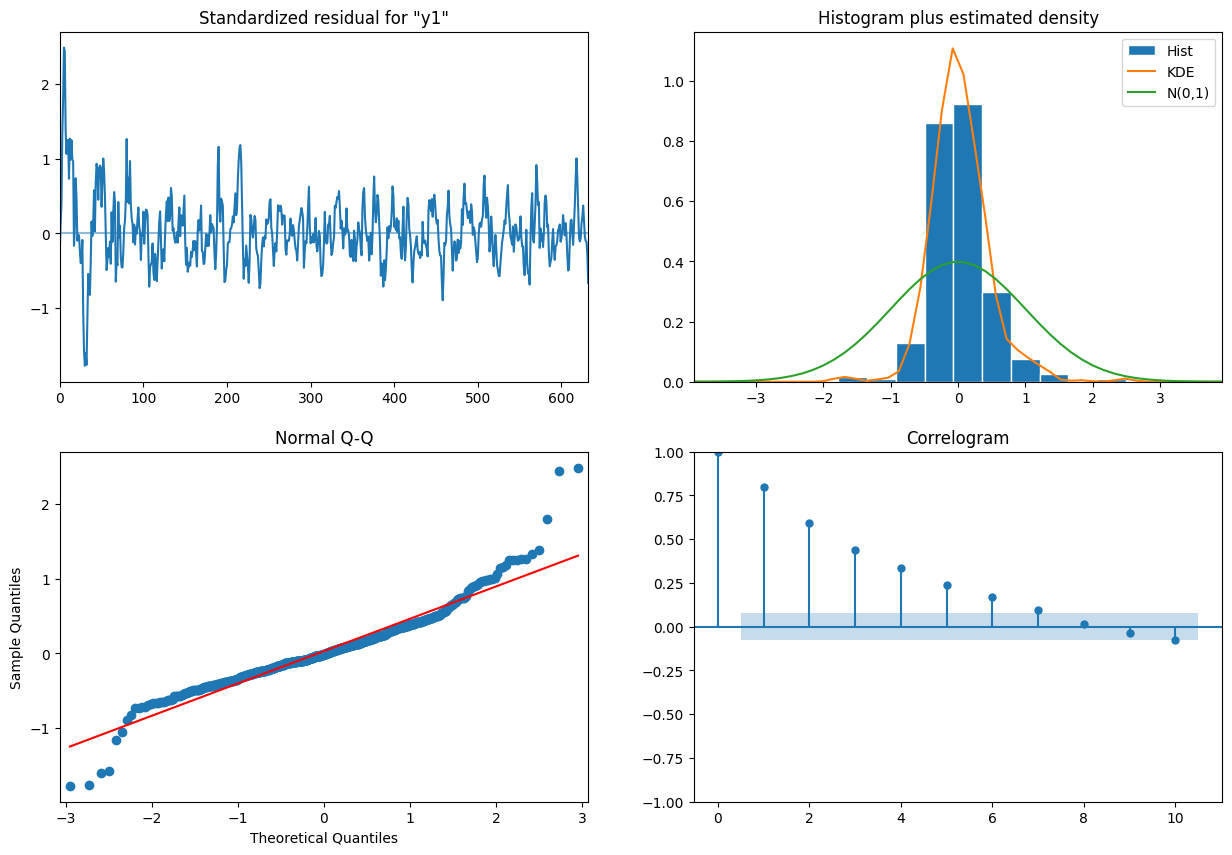

c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 4)   Log Likelihood                2077.790
Date:                Wed, 29 Jul 2026   AIC                          -4141.579
Time:                        12:23:16   BIC                          -4110.327
Sample:                             0   HQIC                         -4129.451
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept  -7.483e-05      0.001     -0.054      0.957      -0.003       0.003
ar.L1          0.9477      0.014     69.848      0.000       0.921       0.974
ma.L1          0.5128      0.022     22.960      0.0

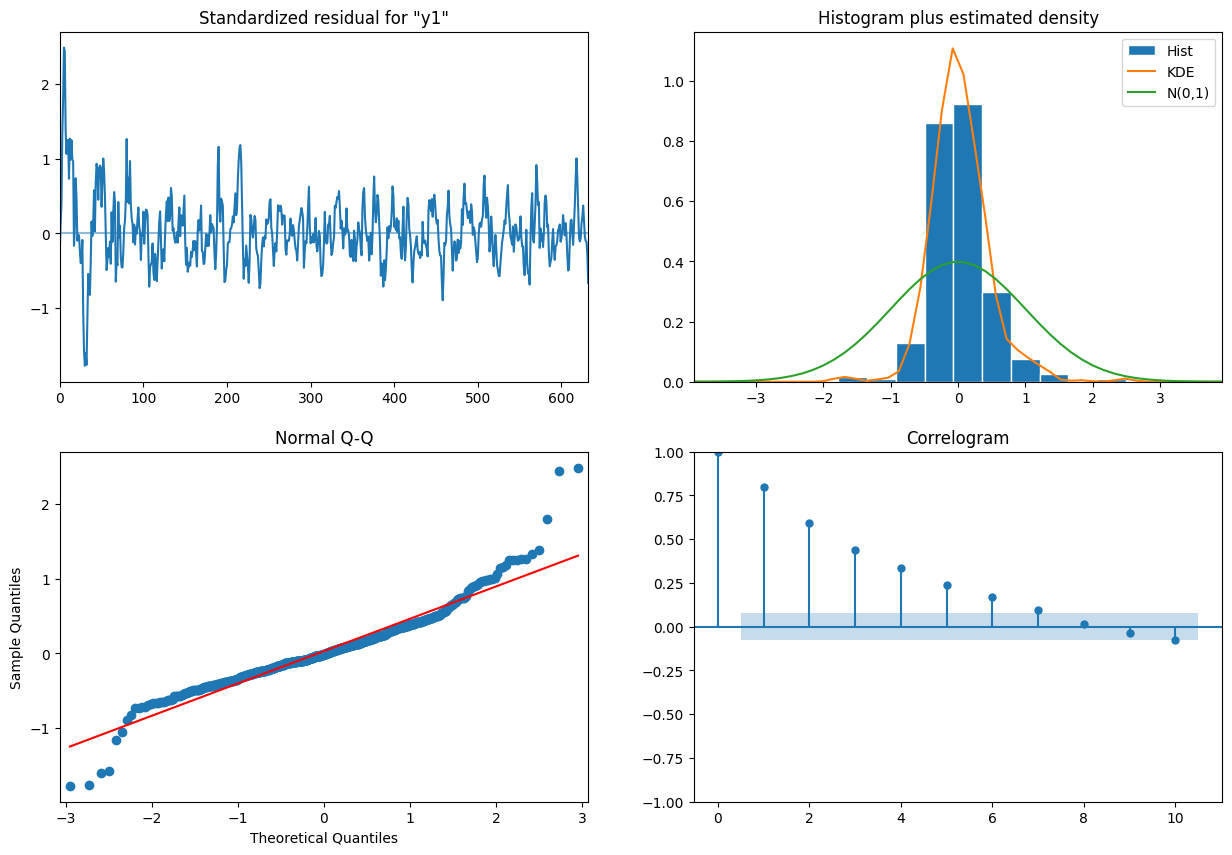

In [23]:
for var in [z, Thv, RH, u, v]:
    # Setup the model
    mod = sm.tsa.statespace.SARIMAX(var, trend='c', order=(1,1,4))

    # Fit it using MLE (recall that we are fitting the three variance parameters)
    res = mod.fit(disp=False)
    print(res.summary())
    fig=results.plot_diagnostics()
    fig.set_size_inches(15,10)
    plt.show(block=True)


                        Exponential Smoothing Results                         
Dep. Variable:                      y   No. Observations:                  643
Model:                   ETS(A, N, N)   Log Likelihood               -2019.924
Date:                Wed, 29 Jul 2026   AIC                           4045.847
Time:                        12:28:07   BIC                           4059.246
Sample:                             0   HQIC                          4051.047
                                - 643   Scale                           31.341
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
smoothing_level     0.9999      0.040     25.260      0.000       0.922       1.077
initial_level      61.3814   4.82e+04      0.001      0.999   -9.44e+04    9.45e+04
Ljung-Box (L1) (Q):             

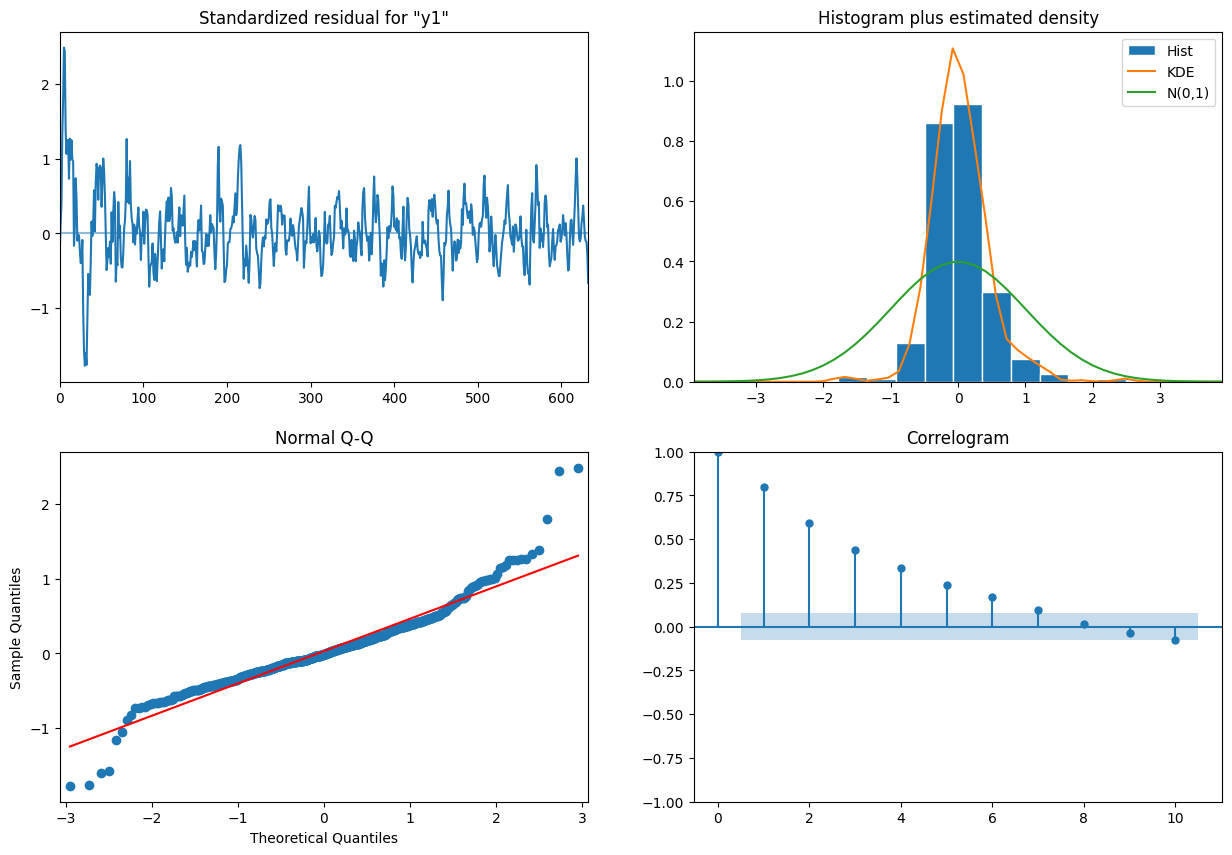

                        Exponential Smoothing Results                         
Dep. Variable:                      y   No. Observations:                  643
Model:                   ETS(A, N, N)   Log Likelihood                 749.879
Date:                Wed, 29 Jul 2026   AIC                          -1493.759
Time:                        12:28:08   BIC                          -1480.360
Sample:                             0   HQIC                         -1488.559
                                - 643   Scale                            0.006
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
smoothing_level     0.9999      0.021     46.928      0.000       0.958       1.042
initial_level     292.1886    141.937      2.059      0.040      13.997     570.380
Ljung-Box (L1) (Q):             

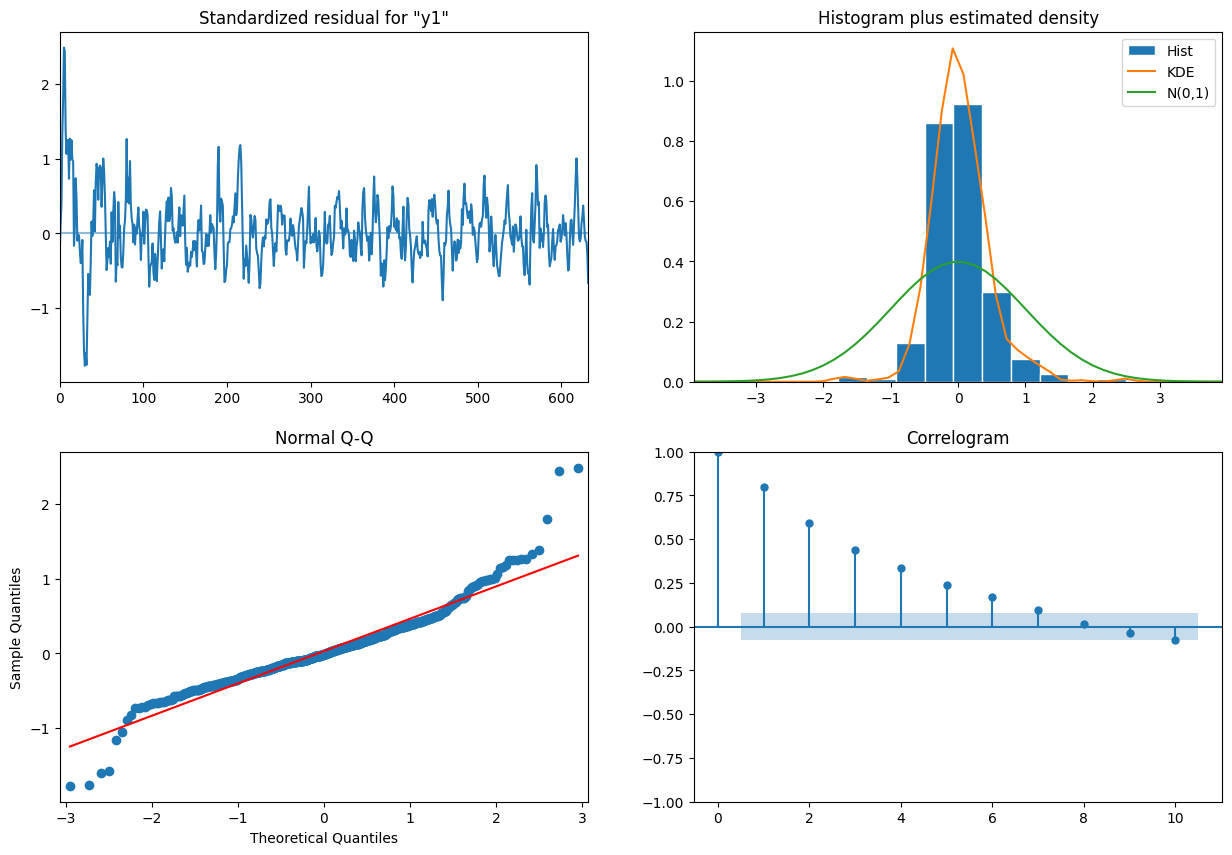

                        Exponential Smoothing Results                         
Dep. Variable:                      y   No. Observations:                  643
Model:                   ETS(A, N, N)   Log Likelihood               -1083.542
Date:                Wed, 29 Jul 2026   AIC                           2173.085
Time:                        12:28:09   BIC                           2186.483
Sample:                             0   HQIC                          2178.284
                                - 643   Scale                            1.703
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
smoothing_level     0.9999      0.015     64.522      0.000       0.970       1.030
initial_level      73.0296    241.987      0.302      0.763    -401.256     547.315
Ljung-Box (L1) (Q):             

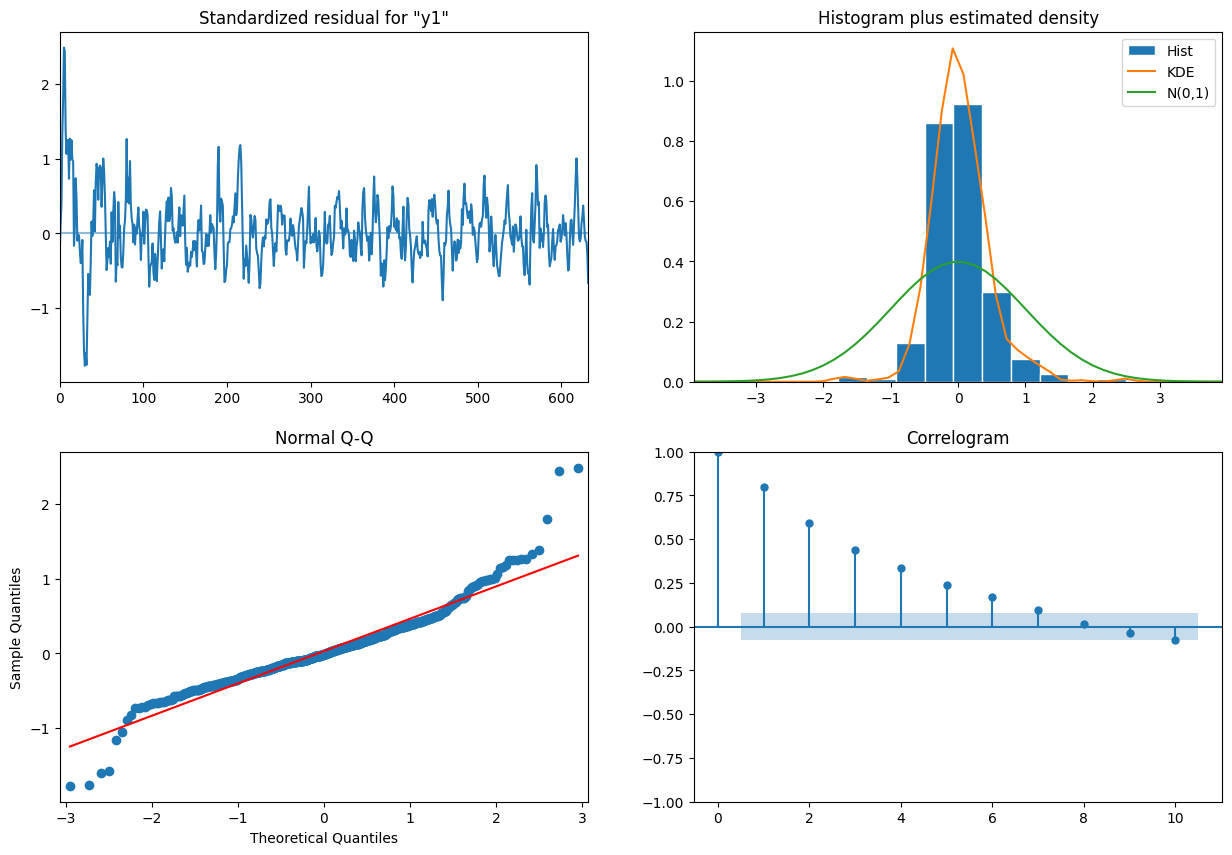

                        Exponential Smoothing Results                         
Dep. Variable:                      y   No. Observations:                  643
Model:                   ETS(A, N, N)   Log Likelihood                 402.057
Date:                Wed, 29 Jul 2026   AIC                           -798.113
Time:                        12:28:10   BIC                           -784.715
Sample:                             0   HQIC                          -792.914
                                - 643   Scale                            0.017
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
smoothing_level     0.9999      0.019     51.618      0.000       0.962       1.038
initial_level      -0.5876   2774.402     -0.000      1.000   -5438.315    5437.140
Ljung-Box (L1) (Q):             

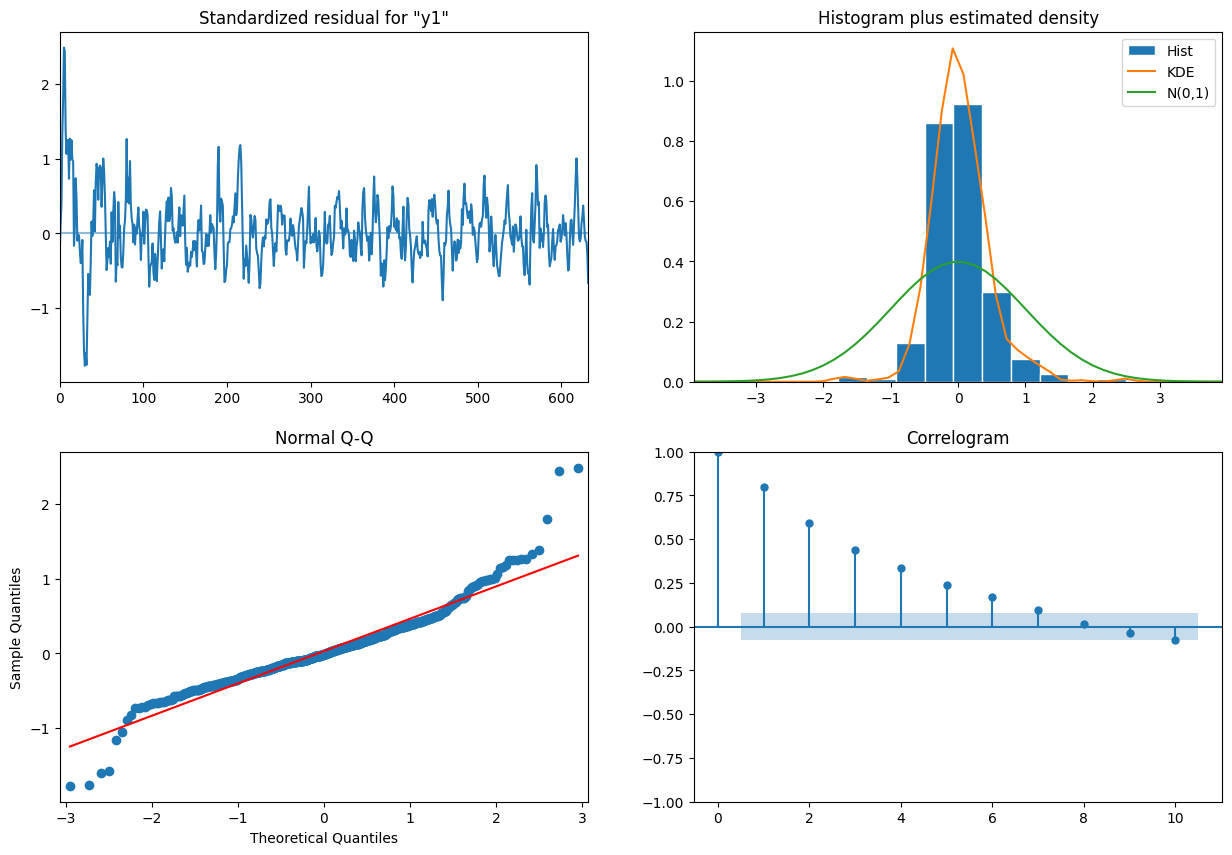

                        Exponential Smoothing Results                         
Dep. Variable:                      y   No. Observations:                  643
Model:                   ETS(A, N, N)   Log Likelihood                 547.531
Date:                Wed, 29 Jul 2026   AIC                          -1089.063
Time:                        12:28:12   BIC                          -1075.664
Sample:                             0   HQIC                         -1083.863
                                - 643   Scale                            0.011
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
smoothing_level     0.9999      0.039     25.318      0.000       0.922       1.077
initial_level       0.3801    258.403      0.001      0.999    -506.081     506.842
Ljung-Box (L1) (Q):             

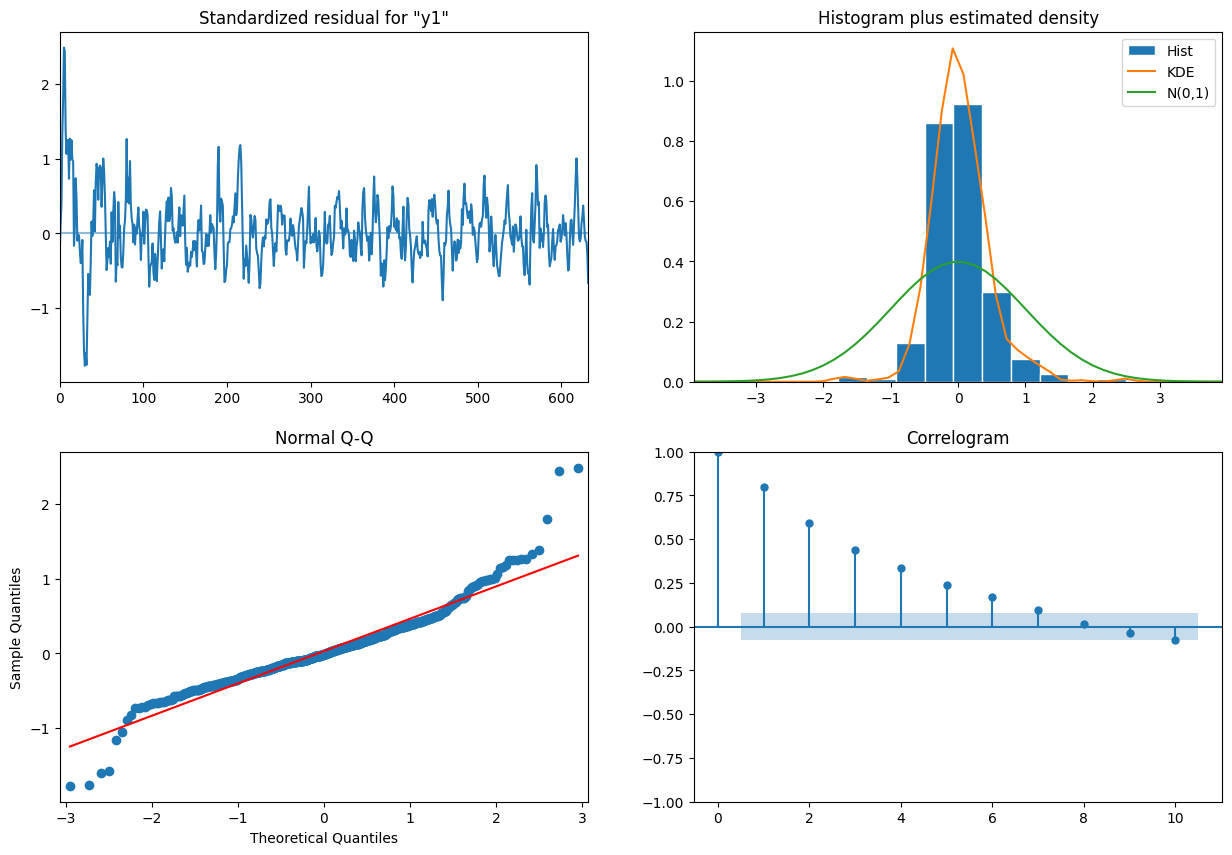

In [25]:
for var in [z, Thv, RH, u, v]:
    # Setup the model
    mod = sm.tsa.statespace.ExponentialSmoothing(var)

    # Fit it using MLE (recall that we are fitting the three variance parameters)
    res = mod.fit(disp=False)
    print(res.summary())
    fig=results.plot_diagnostics()
    fig.set_size_inches(15,10)
    plt.show(block=True)


c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['k_factors', 'factor_order']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               Dynamic Factor Results                              
Dep. Variable:                           y   No. Observations:                  643
Model:                Dynamic Factor Model   Log Likelihood                2435.320
                   + 1 factors in 1 blocks   AIC                          -4860.640
                     + AR(1) idiosyncratic   BIC                          -4838.309
Date:                     Wed, 29 Jul 2026   HQIC                         -4851.974
Time:                             12:30:13   EM Iterations                        3
Sample:                                  0                                         
                                     - 643                                         
Covariance Type:              Not computed                                         
                    Observation equation:                     
Factor loadings:          0    idiosyncratic: AR(1)       var.
----------------------------------

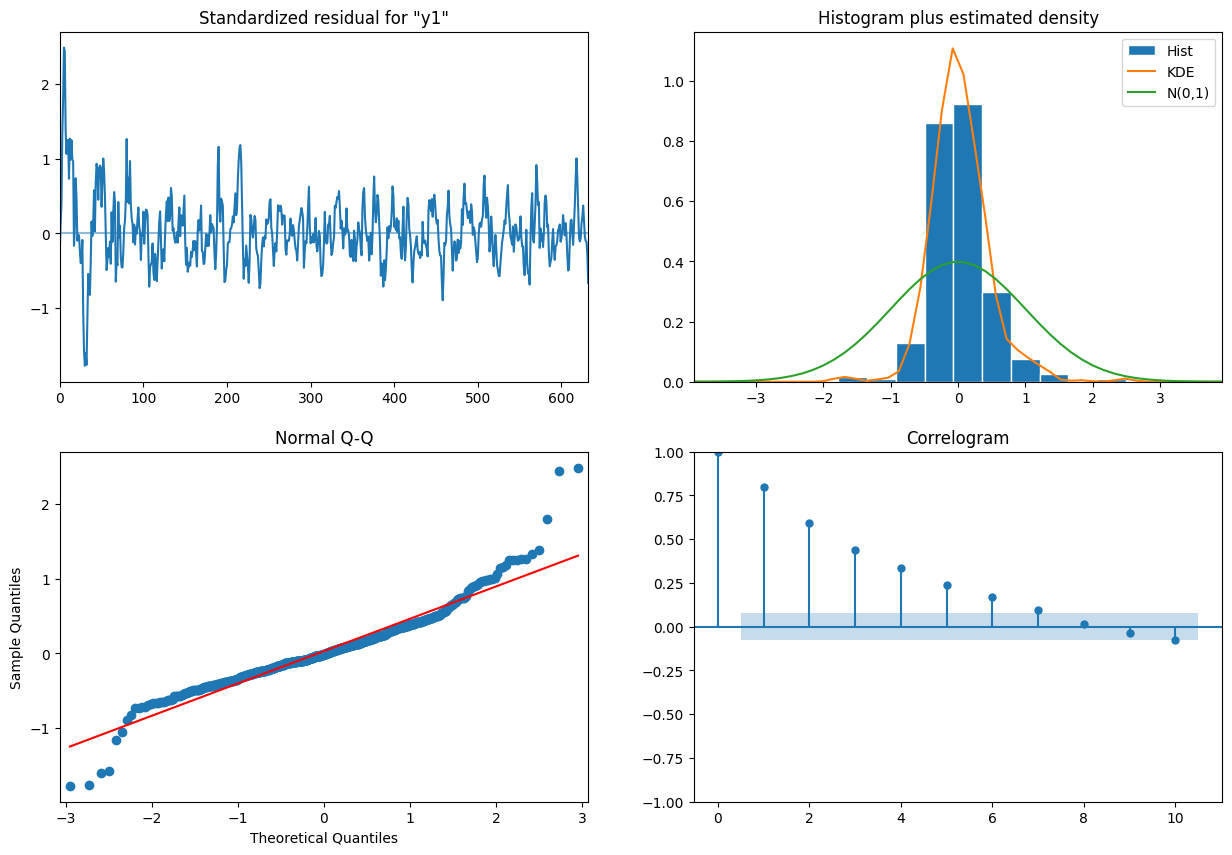

c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['k_factors', 'factor_order']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               Dynamic Factor Results                              
Dep. Variable:                           y   No. Observations:                  643
Model:                Dynamic Factor Model   Log Likelihood                1752.556
                   + 1 factors in 1 blocks   AIC                          -3495.112
                     + AR(1) idiosyncratic   BIC                          -3472.781
Date:                     Wed, 29 Jul 2026   HQIC                         -3486.446
Time:                             12:30:14   EM Iterations                       18
Sample:                                  0                                         
                                     - 643                                         
Covariance Type:              Not computed                                         
                    Observation equation:                     
Factor loadings:          0    idiosyncratic: AR(1)       var.
----------------------------------

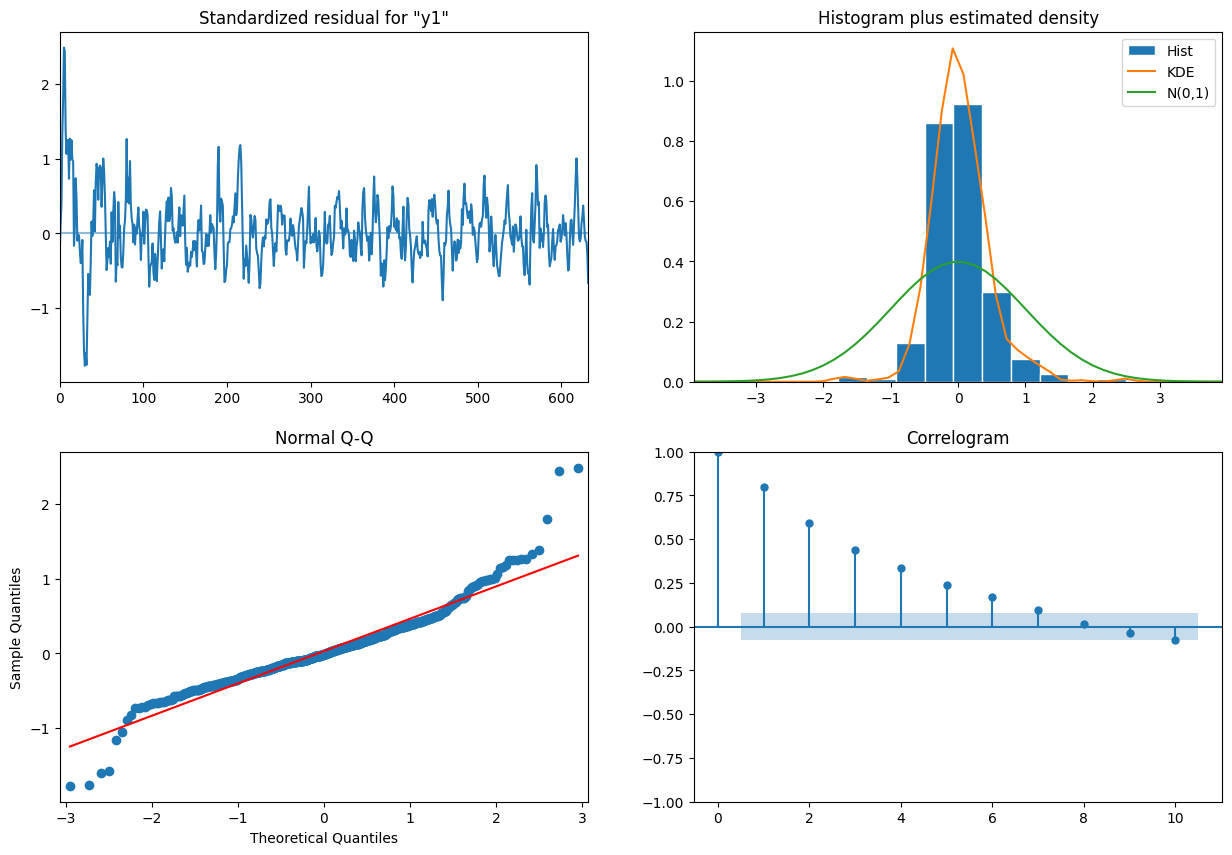

c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['k_factors', 'factor_order']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               Dynamic Factor Results                              
Dep. Variable:                           y   No. Observations:                  643
Model:                Dynamic Factor Model   Log Likelihood                 702.837
                   + 1 factors in 1 blocks   AIC                          -1395.675
                     + AR(1) idiosyncratic   BIC                          -1373.344
Date:                     Wed, 29 Jul 2026   HQIC                         -1387.009
Time:                             12:30:16   EM Iterations                      338
Sample:                                  0                                         
                                     - 643                                         
Covariance Type:              Not computed                                         
                    Observation equation:                     
Factor loadings:          0    idiosyncratic: AR(1)       var.
----------------------------------

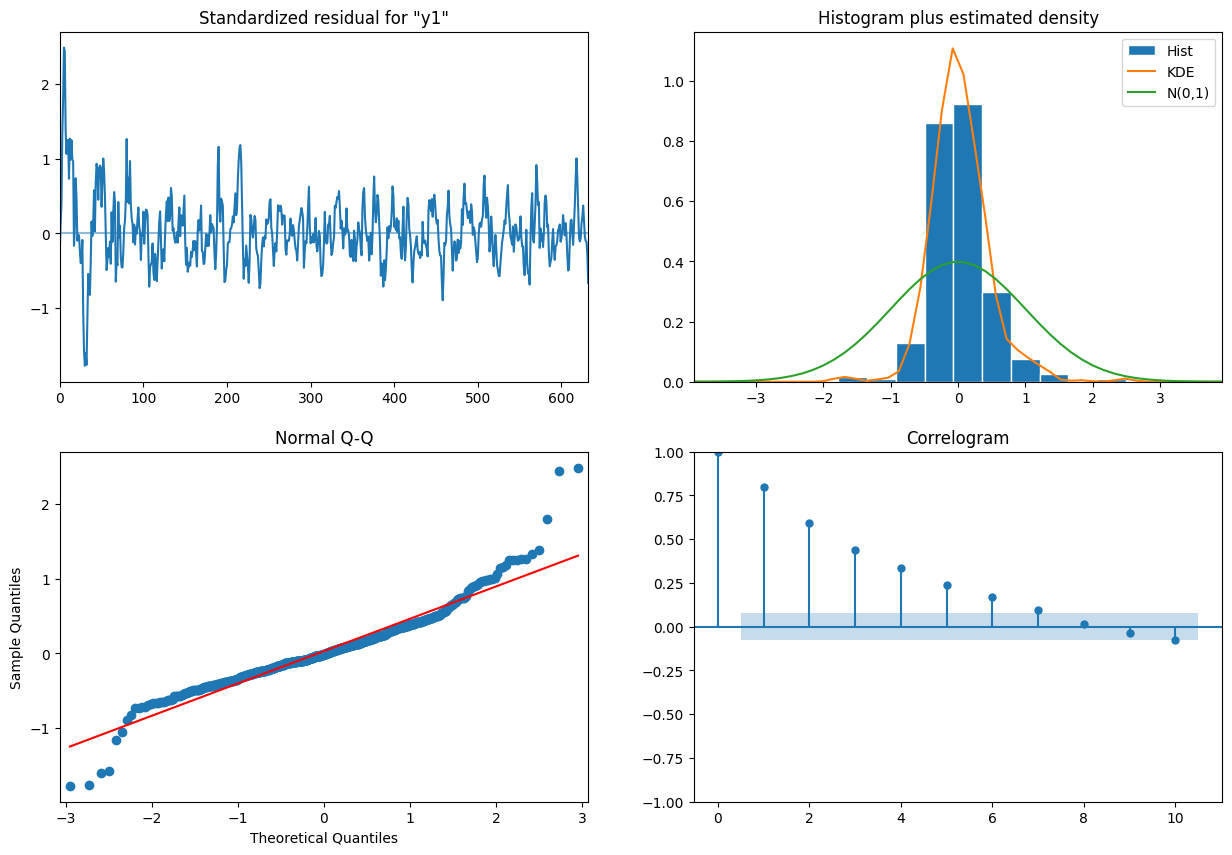

c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['k_factors', 'factor_order']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               Dynamic Factor Results                              
Dep. Variable:                           y   No. Observations:                  643
Model:                Dynamic Factor Model   Log Likelihood                1479.498
                   + 1 factors in 1 blocks   AIC                          -2948.997
                     + AR(1) idiosyncratic   BIC                          -2926.666
Date:                     Wed, 29 Jul 2026   HQIC                         -2940.331
Time:                             12:30:17   EM Iterations                        4
Sample:                                  0                                         
                                     - 643                                         
Covariance Type:              Not computed                                         
                    Observation equation:                     
Factor loadings:          0    idiosyncratic: AR(1)       var.
----------------------------------

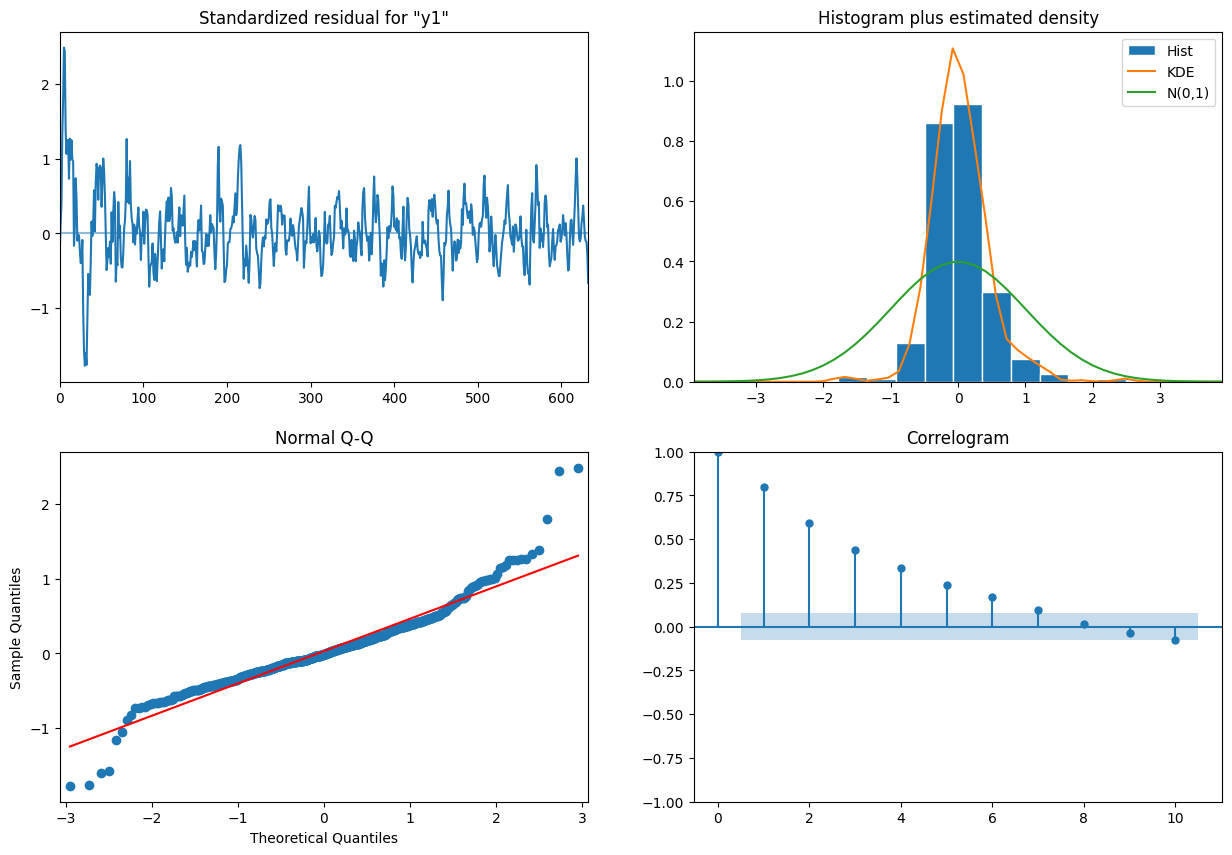

c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['k_factors', 'factor_order']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


                               Dynamic Factor Results                              
Dep. Variable:                           y   No. Observations:                  643
Model:                Dynamic Factor Model   Log Likelihood                 878.967
                   + 1 factors in 1 blocks   AIC                          -1747.934
                     + AR(1) idiosyncratic   BIC                          -1725.604
Date:                     Wed, 29 Jul 2026   HQIC                         -1739.268
Time:                             12:30:19   EM Iterations                       99
Sample:                                  0                                         
                                     - 643                                         
Covariance Type:              Not computed                                         
                    Observation equation:                     
Factor loadings:          0    idiosyncratic: AR(1)       var.
----------------------------------

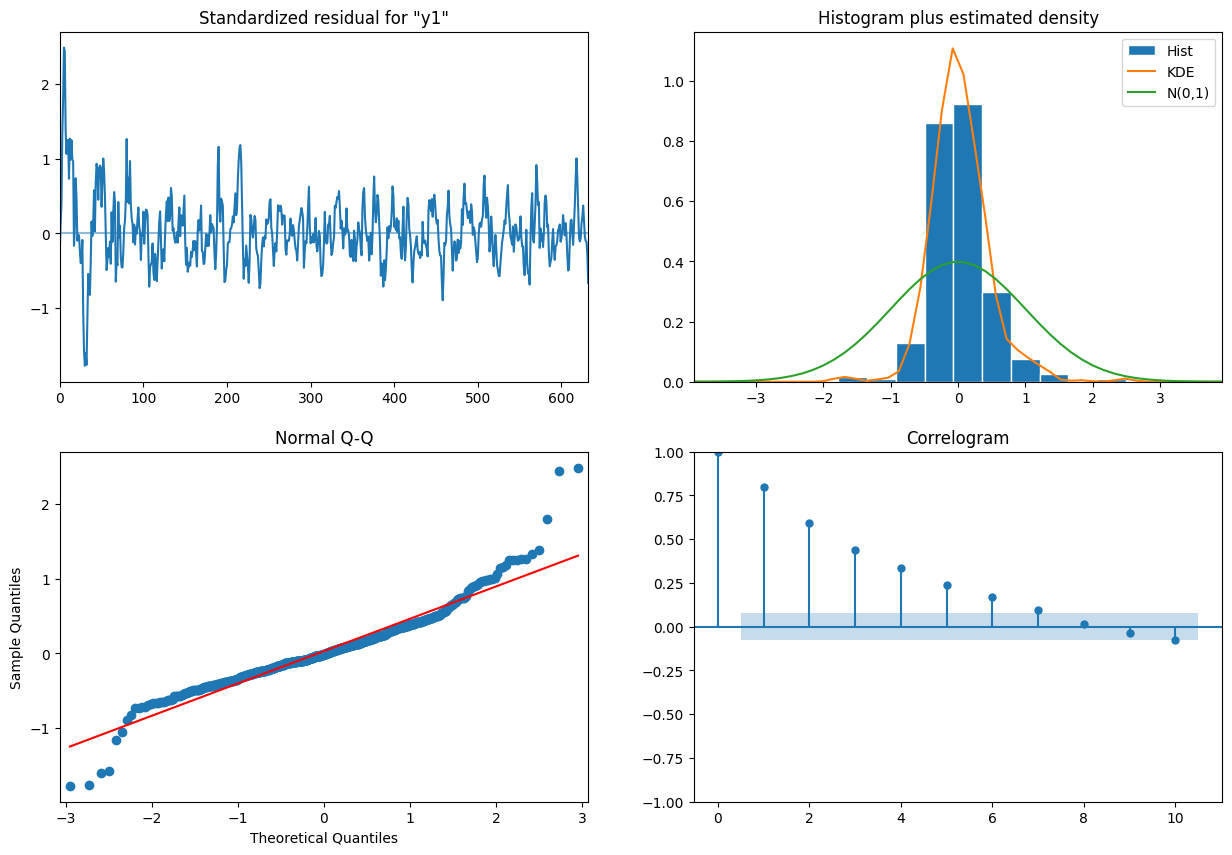

In [26]:
for var in [z, Thv, RH, u, v]:
    # Setup the model
    mod = sm.tsa.DynamicFactorMQ(var, k_factors=1, factor_order=2)

    # Fit it using MLE (recall that we are fitting the three variance parameters)
    res = mod.fit(disp=False)
    print(res.summary())
    fig=results.plot_diagnostics()
    fig.set_size_inches(15,10)
    plt.show(block=True)
